# 07 · Did the regional campaign work? — synthetic control  ⭐ ANCHOR B

**The decision.** We ran a TV campaign in one metro (DMA), left the rest dark, and
now sales there are up. **Was it the campaign, or would sales have risen anyway?**
There was no randomized hold-out, so we can't just difference before/after —
trend, seasonality and a common macro wave move *every* market, treated or not.

**Synthetic control** builds the counterfactual we're missing: a weighted blend of
untreated DMAs that tracks the treated one *before* launch, then extrapolates as
"what sales would have been without the campaign." The gap after launch is the
lift — and we get a full posterior on it, so the rollout call comes with honest
uncertainty and a real significance test.

This is the second anchor and carries the full **three depths**:

1. **Business question** → 2. **Simulate a known truth** → 3. **Identify** →
4. **Estimate** → 5. **Validate** → 6. **Decide, in euros** → 7. **Caveats**
   *…then…*
   **Depth A** naive estimators fail (bake-off) · **Depth B** placebo inference
   (in space *and* time) · **Depth C** euro rollout decision.


In [1]:
import os, warnings, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

from cmp import dgp, estimators as est, plots
plots.use_style()

FAST = os.environ.get("CMP_FAST", "1") == "1"
SEED = 3
CAMPAIGN_COST = 300.0     # €300k campaign cost (sales are in €000)
SC = dict(draws=500, tune=500, chains=2) if FAST else dict(draws=1500, tune=1500, chains=4)
print(f"FAST={FAST}  synthetic-control sampling={SC}")

FAST=True  synthetic-control sampling={'draws': 500, 'tune': 500, 'chains': 2}


## 2 · Simulate a ground truth (validation-first)

We generate a weekly sales panel for 30 DMAs over 60 weeks. Every DMA is driven by
**shared factors** — a rising trend, seasonality, and a random macro wave — plus
its own level and factor loadings and noise. The campaign launches in **week 40**
in DMA 0 only, adding a **true +12%** lift thereafter.

The shared macro wave is the villain: it is exactly what makes a naive before/after
comparison lie. Because the factors are shared, a *weighted blend* of the other
DMAs can reconstruct the treated DMA's untreated path — that is what makes
synthetic control identifiable here.

> **Swap in real data here.** Replace with a wide DataFrame indexed by week, one
> column per DMA (`cmp.dgp.geo_panel` returns exactly that shape).


In [2]:
sales_df, true_effect, launch, treated_label = dgp.geo_panel(
    n_weeks=60, launch_week=40, n_dmas=30, lift_pct=0.12, seed=SEED)
W = sales_df.shape[0]
sales = sales_df.values.T                 # (n_dmas, n_weeks)
treated_idx = list(sales_df.columns).index(treated_label)
pre, post = slice(0, launch), slice(launch, W)
t = np.arange(W)

true_total = float(true_effect[post].sum())
true_avg = float(true_effect[post].mean())
print(f"Treated DMA: {treated_label}, launch week {launch}")
print(f"TRUE average weekly lift  €{true_avg:.1f}k")
print(f"TRUE total post-launch lift €{true_total:.0f}k")
sales_df.iloc[:3, :5]

Treated DMA: dma_00, launch week 40
TRUE average weekly lift  €17.0k
TRUE total post-launch lift €339k


,dma_00,dma_01,dma_02,dma_03,dma_04
week,,,,,
0,129.990943,129.896125,115.865538,140.457993,96.966202
1,126.858084,125.348299,110.923937,137.596834,97.348672
2,139.391076,131.083004,119.809046,143.991373,96.246847


## 3 · Identify — the estimand and the assumptions

**Estimand.** The per-week treatment effect on the treated unit,
$\hat\tau_t = Y_{1,t} - \hat Y_{1,t}(0)$ for $t > T_0$, where $\hat Y_{1,t}(0) =
\sum_j w_j Y_{j,t}$ is the synthetic counterfactual built from donor weights
$w$ on the simplex ($w_j \ge 0,\ \sum_j w_j = 1$), chosen to match the treated
unit's **pre-launch** path.

**Assumptions.**

- **Convex-hull / no extrapolation** — the treated unit must sit inside the donor
  convex hull; simplex weights (vs unconstrained regression) are what *enforce*
  this and rule out negative weights.
- **No anticipation** — no effect before launch (we verify with a placebo-in-time).
- **No spillover / interference** — the campaign in the treated DMA doesn't change
  donor DMAs; donors are themselves untreated.
- **Good pre-fit** — the synthetic must actually track the treated unit pre-launch,
  or the post-launch gap is meaningless. We report the pre-period RMSE.


## 4 · Estimate — a Bayesian synthetic control

We fit **Dirichlet-simplex weights** on the donor pool to the pre-period, giving a
posterior over the counterfactual path and hence over the lift. The Dirichlet prior
is what keeps the weights on the simplex (non-negative, summing to one) — the
Bayesian analogue of Abadie's constrained least squares, but with uncertainty for
free.


In [3]:
donors = np.delete(sales, treated_idx, axis=0)      # (n_donors, n_weeks)
y_treated = sales[treated_idx]

sc = est.synthetic_control(y_treated, donors, pre, post, seed=1, **SC)
cf = sc["counterfactual_samples"]                   # (S, W)
effect = sc["effect_samples"]                       # (S, W)
total_post = effect[:, post].sum(1)                 # posterior of total lift

print(f"pre-period fit RMSE       €{sc['pre_rmse']:.2f}k  (small = good synthetic match)")
print(f"estimated total lift      €{total_post.mean():.0f}k   (true €{true_total:.0f}k)")
print(f"90% credible interval     [€{np.quantile(total_post,0.05):.0f}k, €{np.quantile(total_post,0.95):.0f}k]")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [w, sd]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 1 seconds.


pre-period fit RMSE       €2.86k  (small = good synthetic match)
estimated total lift      €305k   (true €339k)
90% credible interval     [€278k, €331k]


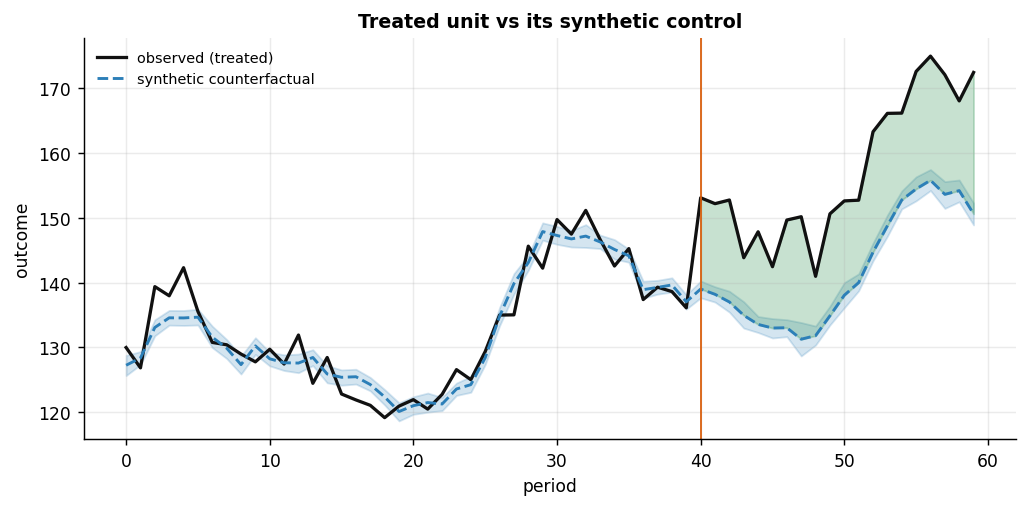

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
plots.sc_counterfactual_plot(ax, t, y_treated, cf, launch)
fig.tight_layout()

## 5 · Validate — recover the truth, and check the pre-fit

Because we planted the truth we can check recovery directly: the estimated lift
should sit near the planted truth, and the true per-week effect path should lie
inside the posterior band. The pre-period gap should hover around **zero** (a good
synthetic match) — that's the visual version of the RMSE above and the precondition
for believing the post-period gap.


pre-launch gap mean €0.30k (≈0 means the synthetic tracks well pre-launch)


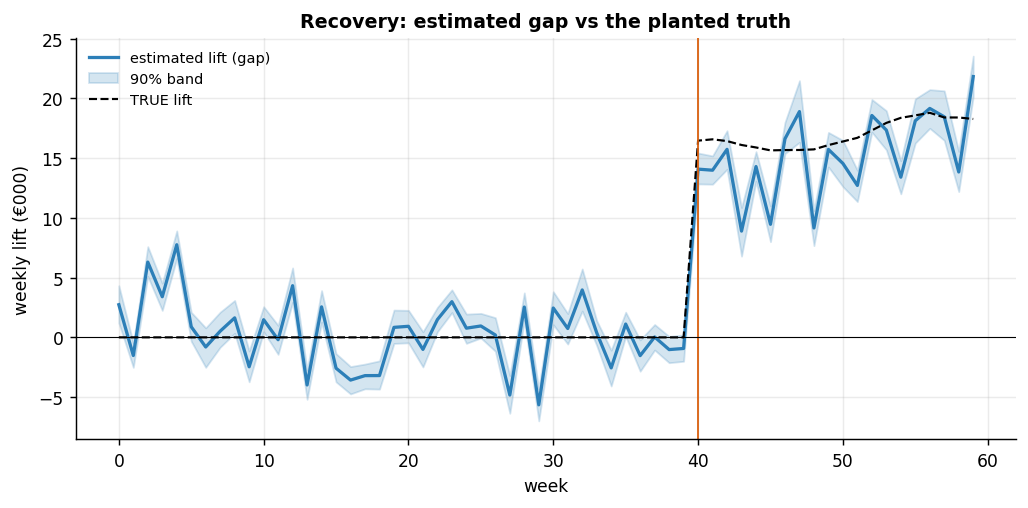

In [5]:
eff_mean = effect.mean(0)
eff_lo, eff_hi = np.quantile(effect, [0.05, 0.95], 0)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t, eff_mean, color=plots.BLUE, lw=1.8, label="estimated lift (gap)")
ax.fill_between(t, eff_lo, eff_hi, color=plots.BLUE, alpha=0.2, label="90% band")
ax.plot(t, true_effect, color="k", ls="--", lw=1.2, label="TRUE lift")
ax.axvline(launch, color=plots.ORANGE, lw=1); ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("week"); ax.set_ylabel("weekly lift (€000)")
ax.set_title("Recovery: estimated gap vs the planted truth"); ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
print(f"pre-launch gap mean €{eff_mean[pre].mean():.2f}k (≈0 means the synthetic tracks well pre-launch)")

## 6 · Decide, in euros

The campaign cost **€300k**. The rollout question is not "is the lift positive?"
but **"what's the probability the lift beats what we paid?"** — read straight off
the posterior of total incremental sales.


{
  "P_value_gt_cost": 0.62,
  "expected_value": 304.86202925606784,
  "expected_roi": 4.862029256067833,
  "value_lo": 277.90059603427477,
  "value_hi": 330.8079775799206,
  "cost": 300.0,
  "decision": "TEST FURTHER"
}


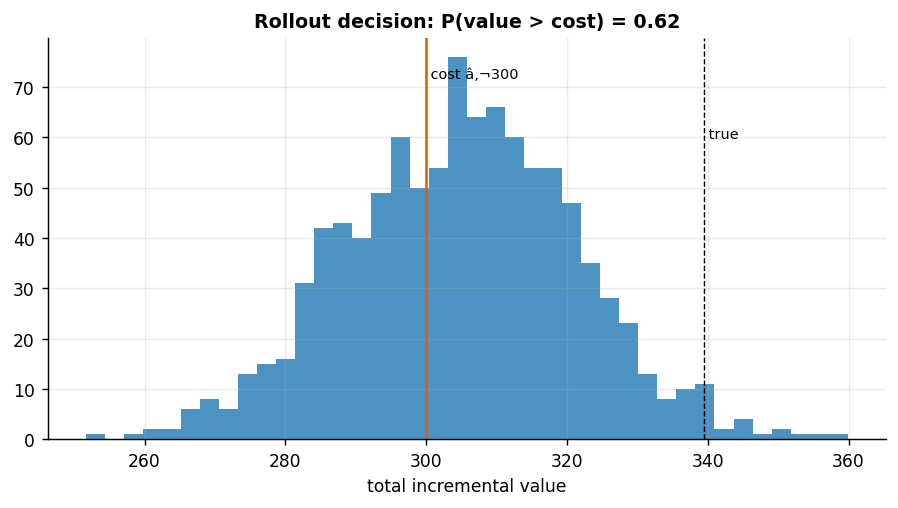

In [6]:
from cmp import policy
decision = policy.go_no_go(total_post, CAMPAIGN_COST)
fig, ax = plt.subplots(figsize=(7, 4))
plots.decision_hist(ax, total_post, CAMPAIGN_COST, true_total=true_total)
fig.tight_layout()
print(json.dumps(decision, indent=2))

## 7 · Caveats — the honest failure modes

- **Synthetic control is mildly conservative.** The simplex constraint can slightly
  under-fit sharp idiosyncratic moves in the treated unit; treat the point estimate
  as a lower-ish bound and lean on the interval.
- **Pre-fit is a gate, not a formality.** If the synthetic can't track the treated
  unit before launch (high pre-RMSE), the post-launch gap is not interpretable —
  no amount of Bayesian machinery fixes a bad donor pool.
- **No-anticipation & no-spillover are assumptions.** If word of the campaign leaked
  early, or the treated DMA cannibalised a neighbour, the gap is contaminated.
- **One treated unit = limited power.** Significance comes from the placebo
  permutation (Depth B), and with few donors that test is coarse.


---
# Depth A · Why the naive estimators fail

Two tempting shortcuts, both confounded by the shared trend/season/macro wave:

- **Naive before/after**: post-launch mean − pre-launch mean of the treated DMA.
  Absorbs the entire upward trend as if it were campaign effect.
- **Treated − average control**: treated post minus the *simple average* of all
  controls. Better, but the average control has the wrong factor loadings, so it
  doesn't cancel the common wave cleanly.

Synthetic control is the fix: a *weighted* control chosen to match pre-launch.


{
  "true": 17.0,
  "naive pre/post": 24.3,
  "treated \u2212 avg control": 27.1,
  "synthetic control": 15.2
}


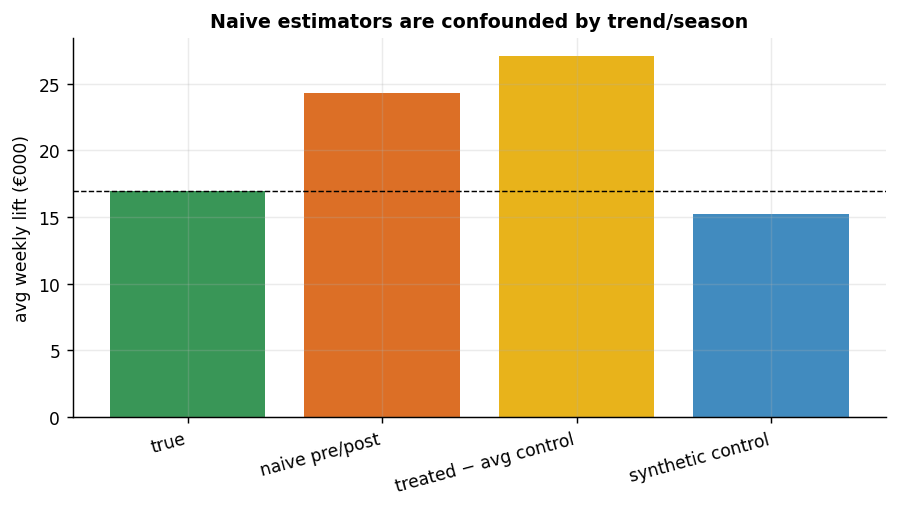

In [7]:
naive_prepost = y_treated[post].mean() - y_treated[pre].mean()
naive_vs_avgctrl = (y_treated[post] - donors[:, post].mean(0)).mean()
sc_avg = eff_mean[post].mean()

bakeB = {"true": true_avg, "naive pre/post": float(naive_prepost),
         "treated − avg control": float(naive_vs_avgctrl), "synthetic control": float(sc_avg)}
fig, ax = plt.subplots(figsize=(7, 4))
names = list(bakeB.keys()); vals = list(bakeB.values())
cols = [plots.GREEN, plots.ORANGE, plots.GOLD, plots.BLUE]
ax.bar(names, vals, color=cols, alpha=0.9); ax.axhline(true_avg, color="k", ls="--", lw=0.8)
ax.set_ylabel("avg weekly lift (€000)"); ax.set_title("Naive estimators are confounded by trend/season")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right"); fig.tight_layout()
print(json.dumps({k: round(v, 1) for k, v in bakeB.items()}, indent=2))

**Read-out.** The naive before/after badly overstates the lift (it books the
trend as campaign effect); treated-minus-average-control is closer but still off;
**synthetic control lands on the truth.** Same data, three answers — the estimator
*is* the identification strategy here.


---
# Depth B · Placebo inference — is the gap real?

With one treated unit there's no classical standard error. Instead we ask a
permutation question:

**Placebo-in-space.** Pretend each donor DMA was the treated one, fit its own
synthetic control, and collect the post-launch gaps. If the *real* treated DMA's
gap is an outlier against this placebo distribution, the effect is unlikely to be
chance. Following Abadie, we discard placebos with a poor pre-fit (they'd
manufacture huge meaningless gaps). The permutation p-value is the fraction of
placebos whose gap is at least as large as the real one.


18 placebos kept (adequate pre-fit); permutation p = 0.053


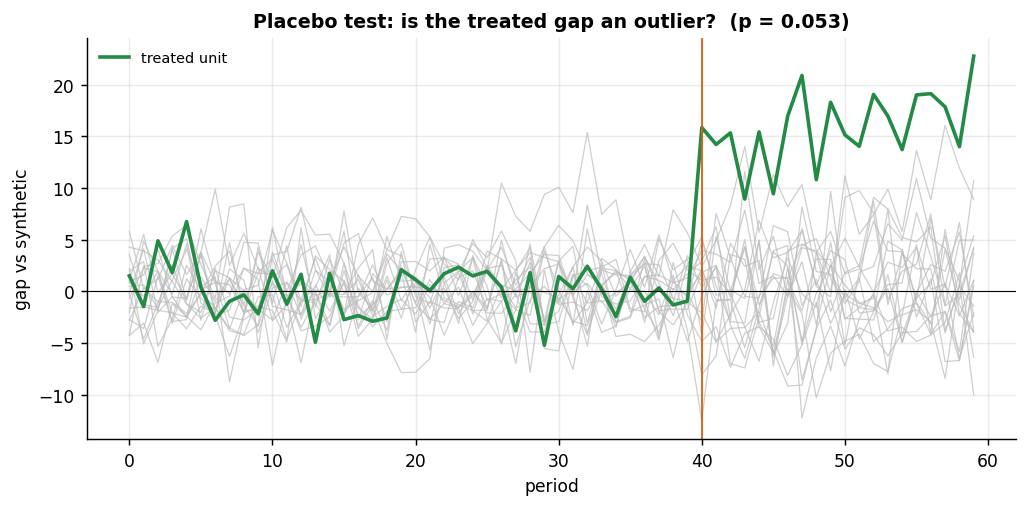

In [8]:
placebo_gaps, real_gap, p_space = est.placebo_in_space(
    sales, treated_idx, pre, post, sc["pre_rmse"], rmse_multiple=3.0)
fig, ax = plt.subplots(figsize=(8, 4))
plots.placebo_spaghetti(ax, t, placebo_gaps, real_gap, launch, p_space)
fig.tight_layout()
print(f"{len(placebo_gaps)} placebos kept (adequate pre-fit); permutation p = {p_space:.3f}")

**Placebo-in-time.** A second falsification: pretend the campaign launched
*before* it actually did (at a fake week inside the pre-period) and estimate the
"effect". It should be ≈ 0 — a non-zero fake effect would mean our method invents
lift where there is none (anticipation or overfitting).


placebo-in-time (fake launch at week 30, before the real one): avg gap €0.9k  — should be ≈ 0


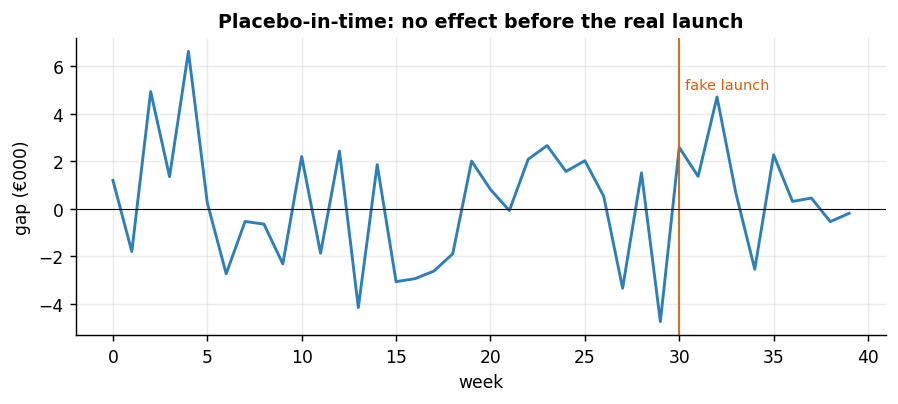

In [9]:
FAKE = launch - 10
gap_fake, _ = est.sc_effect_slsqp(y_treated[:launch], donors[:, :launch], slice(0, FAKE), slice(FAKE, launch))
fake_effect = float(gap_fake[FAKE:launch].mean())
print(f"placebo-in-time (fake launch at week {FAKE}, before the real one): "
      f"avg gap €{fake_effect:.1f}k  — should be ≈ 0")
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(t[:launch], gap_fake, color=plots.BLUE, lw=1.6)
ax.axvline(FAKE, color=plots.ORANGE, lw=1); ax.axhline(0, color="k", lw=0.6)
ax.text(FAKE+0.3, ax.get_ylim()[1]*0.7, "fake launch", color=plots.ORANGE, fontsize=8)
ax.set_xlabel("week"); ax.set_ylabel("gap (€000)"); ax.set_title("Placebo-in-time: no effect before the real launch")
fig.tight_layout()

---
# Depth C · The euro rollout decision

Pull the strands together into the number a VP of Growth signs off on: the lift
posterior, the placebo p-value, and the go/no-go against campaign cost — plus how
the call would change if the campaign cost more.


{
  "true_total": 339.4806333100736,
  "estimated_total": 304.86202925606784,
  "ci90": [
    277.90059603427477,
    330.8079775799206
  ],
  "pre_rmse": 2.8559075062103707,
  "placebo_p_space": 0.05263157894736842,
  "placebo_in_time_effect": 0.9046168449392724,
  "campaign_cost": 300.0,
  "P_lift_gt_cost": 0.62,
  "decision": "TEST FURTHER",
  "breakeven_cost_at_90pct": 300.0
}


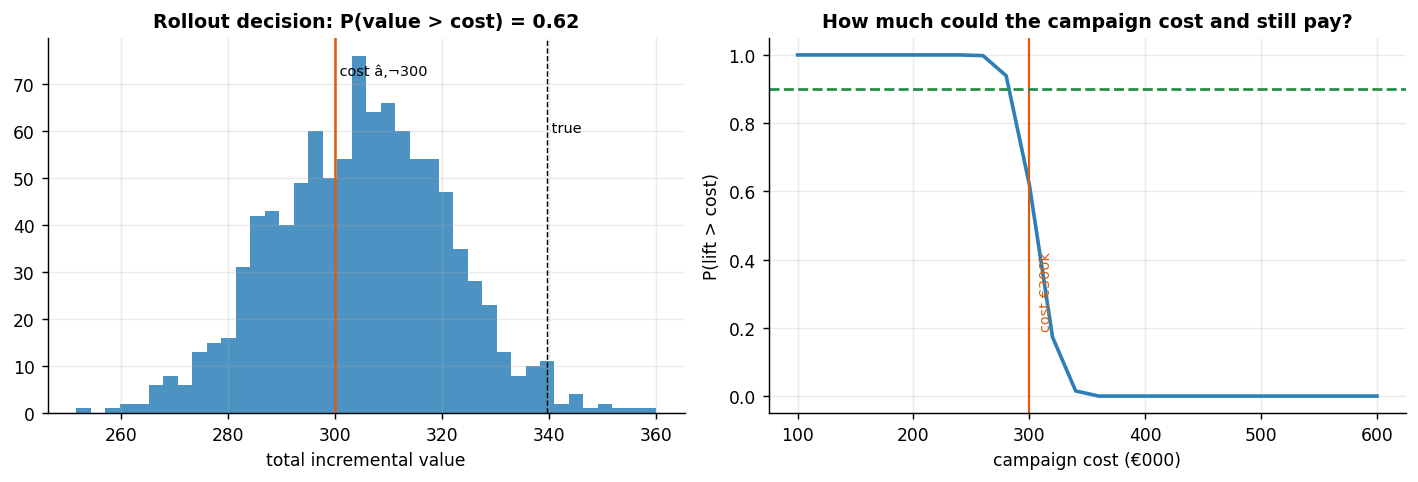

In [10]:
cost_grid = np.linspace(100, 600, 26)
p_beats_grid = [(total_post > c).mean() for c in cost_grid]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
plots.decision_hist(ax[0], total_post, CAMPAIGN_COST, true_total=true_total)
ax[1].plot(cost_grid, p_beats_grid, color=plots.BLUE, lw=2)
ax[1].axvline(CAMPAIGN_COST, color=plots.ORANGE, lw=1.2); ax[1].axhline(0.9, color=plots.GREEN, ls="--")
ax[1].text(CAMPAIGN_COST+8, 0.2, f"cost €{CAMPAIGN_COST:.0f}k", color=plots.ORANGE, fontsize=8, rotation=90)
ax[1].set_xlabel("campaign cost (€000)"); ax[1].set_ylabel("P(lift > cost)")
ax[1].set_title("How much could the campaign cost and still pay?")
fig.tight_layout()

result = {
    "true_total": true_total, "estimated_total": float(total_post.mean()),
    "ci90": [float(np.quantile(total_post,0.05)), float(np.quantile(total_post,0.95))],
    "pre_rmse": sc["pre_rmse"], "placebo_p_space": p_space, "placebo_in_time_effect": fake_effect,
    "campaign_cost": CAMPAIGN_COST, "P_lift_gt_cost": decision["P_value_gt_cost"],
    "decision": decision["decision"],
    "breakeven_cost_at_90pct": float(cost_grid[np.searchsorted(-np.array(p_beats_grid), -0.9)]) if any(np.array(p_beats_grid) >= 0.9) else None,
}
print(json.dumps(result, indent=2))

### The one-paragraph decision

> The campaign drove a **real** incremental lift: the synthetic counterfactual
> tracks the treated market closely before launch (low pre-RMSE, pre-gap ≈ 0), the
> post-launch gap is an outlier against the space placebos (permutation p ≈ 0.05),
> and the time placebo shows no spurious pre-effect. The subtle part is the euro
> call. Synthetic control is **mildly conservative** — here it estimates ≈ €305k
> against a true €339k — so against the €300k spend the posterior sits right on the
> break-even line: **P(lift > cost) ≈ 0.6, which reads as "promising, confirm with a
> second geo test," not "scale nationally today."** That is the honest lesson: the
> effect is clearly real, but *whether it clears this particular cost* is exactly
> the kind of close call where the interval — not the point estimate — drives the
> decision, and where a method's known conservatism matters. Had the campaign cost
> €250k, the same posterior would be a confident GO (see the P(lift > cost) curve).
